# Analyse multidimensionnelle des trajectoires de soins pour le jeu de données `multidimensional_data`

Ce notebook présente l'application du package `trajectoryclusteringanalysis` sur un jeu de données de traitements d'un cancer exprimé en mois.

1. Configuration de l'environnement et imports
2. Chargement et préparation des données
3. Initialisation du modèle TCA et construction du tenseur
4. Décomposition par l'algorithme SWoTTeD
5. Clustering sur les intensités des phénotypes

## 1. Imports

In [3]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import random

project_root = None
for base in [Path.cwd(), *Path.cwd().parents]:
    src_candidate = base / "src" / "trajectoryclusteringanalysis"
    if src_candidate.exists():
        project_root = base
        break

if project_root is None:
    raise FileNotFoundError(
        f"Could not find project root containing src/trajectoryclusteringanalysis from {Path.cwd()}"
    )

src_path = project_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from trajectoryclusteringanalysis import TCA
from trajectoryclusteringanalysis.plotting import *

print(f"Using local package from: {src_path}")

from trajectoryclusteringanalysis.tca import TCA

Using local package from: c:\Users\imen.miloudi\OneDrive - Aix-Marseille Université\Documents\stage\TrajectoryClusteringAnalysis\src


## 2. Chargement et préparation des données

In [5]:
df = pd.read_csv(project_root / "data" / "multidimensional_data.csv")
df

,PATIENT_ID,EVENT,TIME
0,1,Chirurgie,0
1,1,Chimiothérapie IV,1
2,1,Chimiothérapie IV,1
3,1,Chimiothérapie IV,2
4,1,Chimiothérapie IV,3
...,...,...,...
20430,1336,Chimiothérapie IV,2
20431,1336,Chimiothérapie IV,2
20432,1336,Chimiothérapie IV,3
20433,1336,Chimiothérapie IV,3


In [6]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
timed_event_structure = df.copy()

timed_event_structure['Event'] = label_encoder.fit_transform(timed_event_structure['EVENT'])
timed_event_structure.drop(columns=['EVENT'], inplace=True)
timed_event_structure.columns = ['ID_PATIENT', 'Time', 'Event']
noms_events = label_encoder.classes_
timed_event_structure

,ID_PATIENT,Time,Event
0,1,0,2
1,1,1,0
2,1,1,0
3,1,2,0
4,1,3,0
...,...,...,...
20430,1336,2,0
20431,1336,2,0
20432,1336,3,0
20433,1336,3,0


In [7]:
nunique = timed_event_structure['ID_PATIENT'].nunique()
print(f"Number of unique patients: {nunique}")

Number of unique patients: 1336


In [8]:
# Get the set of all unique Event values
unique_events = timed_event_structure['Event'].unique()
all_events = set(unique_events)

# Find patients who have all occurrences of Event
patients_with_all_events = timed_event_structure.groupby('ID_PATIENT').filter(
    lambda group: set(group['Event']) == all_events
)['ID_PATIENT'].unique()

print(f"Patients with all occurrences of Event: {len(patients_with_all_events)}")
print(patients_with_all_events)

Patients with all occurrences of Event: 50
[   8   23   45   65   66  134  157  173  176  178  188  194  220  228
  242  275  312  343  361  390  428  466  469  472  478  537  544  546
  575  613  665  673  688  759  775  790  792  831  845  867  895  937
  943  969  984 1081 1126 1286 1293 1333]


## 3. Initialisation du modèle TCA

In [9]:
# Créer une instance de TCA pour l'analyse multidimensionnelle
tca = TCA(data=timed_event_structure,
              index_col='ID_PATIENT',
              time_col='Time', 
              event_col='Event',
              mode='multidimensional',
              )

INFO:root:TCA object initialized successfully
INFO:root:The multidimensional analysis mode is set. TCA object will analyze the data accordingly.


Dataset :
data shape:  (20435, 3)
state coding:
    label  label encoded
0      0              0
1      1              1
2      2              2
3      3              3


In [10]:
tca.analyzer.transform_time_event_structure_to_tensor()
print("Tensor shape:", tca.analyzer.get_tensor_shape())
tensor = tca.analyzer.get_tensor()

Tensor shape: torch.Size([1336, 4, 24])


Patient utilise pour la visualisation: 23


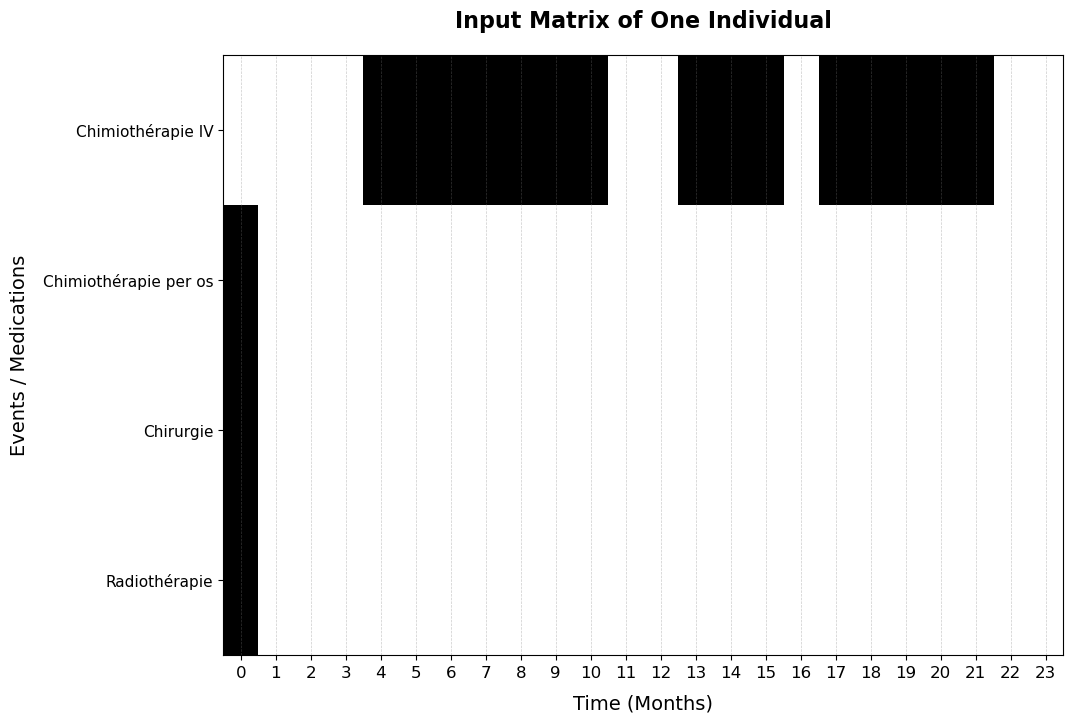

     PATIENT_ID                  EVENT  TIME
561          23              Chirurgie     0
562          23  Chimiothérapie per os     0
563          23          Radiothérapie     0
564          23          Radiothérapie     0
565          23          Radiothérapie     0
566          23          Radiothérapie     0
567          23      Chimiothérapie IV     4
568          23      Chimiothérapie IV     5
569          23      Chimiothérapie IV     5
570          23      Chimiothérapie IV     6
571          23      Chimiothérapie IV     7
572          23      Chimiothérapie IV     7
573          23      Chimiothérapie IV     8
574          23      Chimiothérapie IV     8
575          23      Chimiothérapie IV     9
576          23      Chimiothérapie IV    10
577          23      Chimiothérapie IV    13
578          23      Chimiothérapie IV    13
579          23      Chimiothérapie IV    14
580          23      Chimiothérapie IV    15
581          23      Chimiothérapie IV    17
582       

In [11]:
patient_index = int(patients_with_all_events[1])
print(f"Patient utilise pour la visualisation: {patient_index}")

plot_input_matrix(tensor, id=patient_index, labels=noms_events, time_unit='Months')

print(df[df['PATIENT_ID'] == 23])

## 4. Décomposition du jeu de données à l'aide de l'algorithme SWOTTED

In [12]:
# Hyperparametres de la demo
metric = 'Bernoulli'
learning_rate = 1e-2
n_epochs = 200  # 30 pour demo rapide, 100+ pour entrainement plus stable

In [14]:
ranks = [2, 3, 4, 5]
windows = [2, 3, 4]
sparsities = [0.1, 0.3, 0.5, 0.7, 0.9]
non_successions = [0.1, 0.3, 0.5, 0.7, 0.9]
models = {}

# Nombre max de tests
n_essais_max = 10


for i in range(n_essais_max):
    r = random.choice(ranks)
    w = random.choice(windows)
    s = random.choice(sparsities)
    ns = random.choice(non_successions)
    
    print(f"\n--- Essai {i+1}/{n_essais_max} : R={r}, W={w}, S={s}, NS={ns} ---")
    
    tca.analyzer.fit_swotted_decomposition(
        tensor, rank=r, time_window_length=w, 
        reg_term_ns=ns, reg_term_s=s, metric=metric, 
        learning_rate=learning_rate, n_epochs=n_epochs, fit_metric_every_n_epochs=0 
    )

    models[(r, w, s, ns)] = (tca.analyzer.model, tca.analyzer.W)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.

  | Name         | Type          | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | model        | SlidingWindow | 0      | train | 0    
  | other params | n/a           | 24     | n/a   | n/a  
---------------------------------------------------------------
24        Trainable params
0         Non-trainable params
24        Total params
0.000     Total estimated model params size (MB)
1         Modules in train mode
0         Modules in eval


--- Essai 1/10 : R=2, W=3, S=0.3, NS=0.1 ---


Training: |          | 0/? [00:00<?, ?it/s]

Epoch 1/200 - train_loss: 16.627747
Epoch 2/200 - train_loss: 17.024172
Epoch 3/200 - train_loss: 15.717011
Epoch 4/200 - train_loss: 15.573545
Epoch 5/200 - train_loss: 16.176474
Epoch 6/200 - train_loss: 15.178748
Epoch 7/200 - train_loss: 15.098613
Epoch 8/200 - train_loss: 14.898703
Epoch 9/200 - train_loss: 14.652592
Epoch 10/200 - train_loss: 15.309800
Epoch 11/200 - train_loss: 14.766691
Epoch 12/200 - train_loss: 14.187625
Epoch 13/200 - train_loss: 14.060907
Epoch 14/200 - train_loss: 14.024325
Epoch 15/200 - train_loss: 14.167830
Epoch 16/200 - train_loss: 17.592836
Epoch 17/200 - train_loss: 13.293961
Epoch 18/200 - train_loss: 21.033834
Epoch 19/200 - train_loss: 20.663288
Epoch 20/200 - train_loss: 19.592949
Epoch 21/200 - train_loss: 18.462471
Epoch 22/200 - train_loss: 17.280293
Epoch 23/200 - train_loss: 16.025988
Epoch 24/200 - train_loss: 14.703674
Epoch 25/200 - train_loss: 13.645721
Epoch 26/200 - train_loss: 12.645652
Epoch 27/200 - train_loss: 11.726211
Epoch 28/2

`Trainer.fit` stopped: `max_epochs=200` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.

  | Name         | Type          | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | model        | SlidingWindow | 0      | train | 0    
  | other params | n/a           | 64     | n/a   | n/a  
---------------------------------------------------------------
64        Trainable params
0         Non-trainable params
64        Total params
0.000     Total estimated model params size (MB)
1       

...

`Trainer.fit` stopped: `max_epochs=200` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.

  | Name         | Type          | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | model        | SlidingWindow | 0      | train | 0    
  | other params | n/a           | 64     | n/a   | n/a  
---------------------------------------------------------------
64        Trainable params
0         Non-trainable params
64        Total params
0.000     Total estimated model params size (MB)
1       


--- Essai 10/10 : R=4, W=4, S=0.7, NS=0.1 ---


Training: |          | 0/? [00:00<?, ?it/s]

Epoch 1/200 - train_loss: 16.788572
Epoch 2/200 - train_loss: 20.143454
Epoch 3/200 - train_loss: 21.390350
Epoch 4/200 - train_loss: 14.599401
Epoch 5/200 - train_loss: 14.639548
Epoch 6/200 - train_loss: 14.812056
Epoch 7/200 - train_loss: 14.474364
Epoch 8/200 - train_loss: 30.258312
Epoch 9/200 - train_loss: 26.909693
Epoch 10/200 - train_loss: 22.573563
Epoch 11/200 - train_loss: 18.291260
Epoch 12/200 - train_loss: 15.260821
Epoch 13/200 - train_loss: 13.922611
Epoch 14/200 - train_loss: 13.825307
Epoch 15/200 - train_loss: 32.991524
Epoch 16/200 - train_loss: 32.444736
Epoch 17/200 - train_loss: 31.886818
Epoch 18/200 - train_loss: 31.333328
Epoch 19/200 - train_loss: 30.776417
Epoch 20/200 - train_loss: 30.255753
Epoch 21/200 - train_loss: 29.755510
Epoch 22/200 - train_loss: 29.261673
Epoch 23/200 - train_loss: 28.776701
Epoch 24/200 - train_loss: 28.297495
Epoch 25/200 - train_loss: 27.802227
Epoch 26/200 - train_loss: 27.287838
Epoch 27/200 - train_loss: 26.772108
Epoch 28/2

`Trainer.fit` stopped: `max_epochs=200` reached.


Decomposed into 1336 pathways with rank 3 and time window length 3
Success rate for the entire dataset: -7.6814


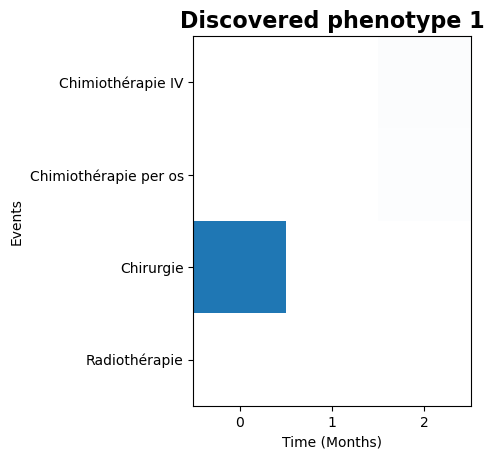

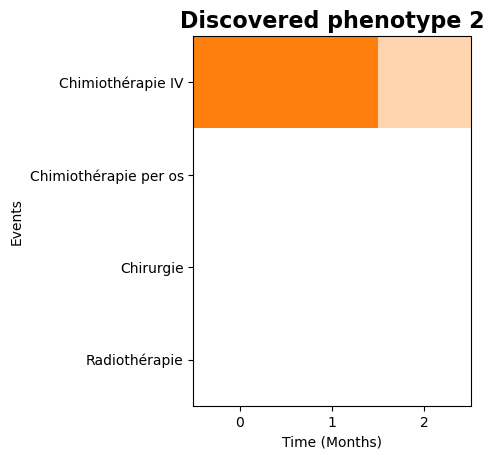

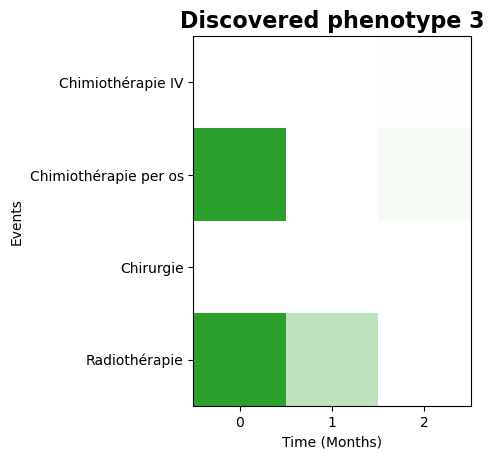

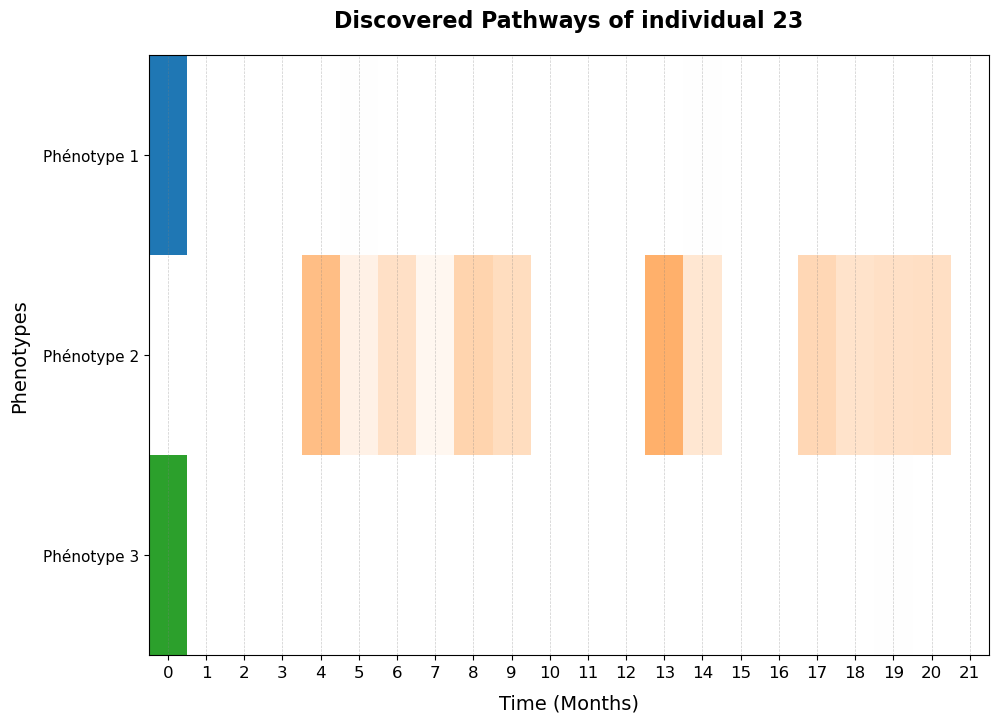

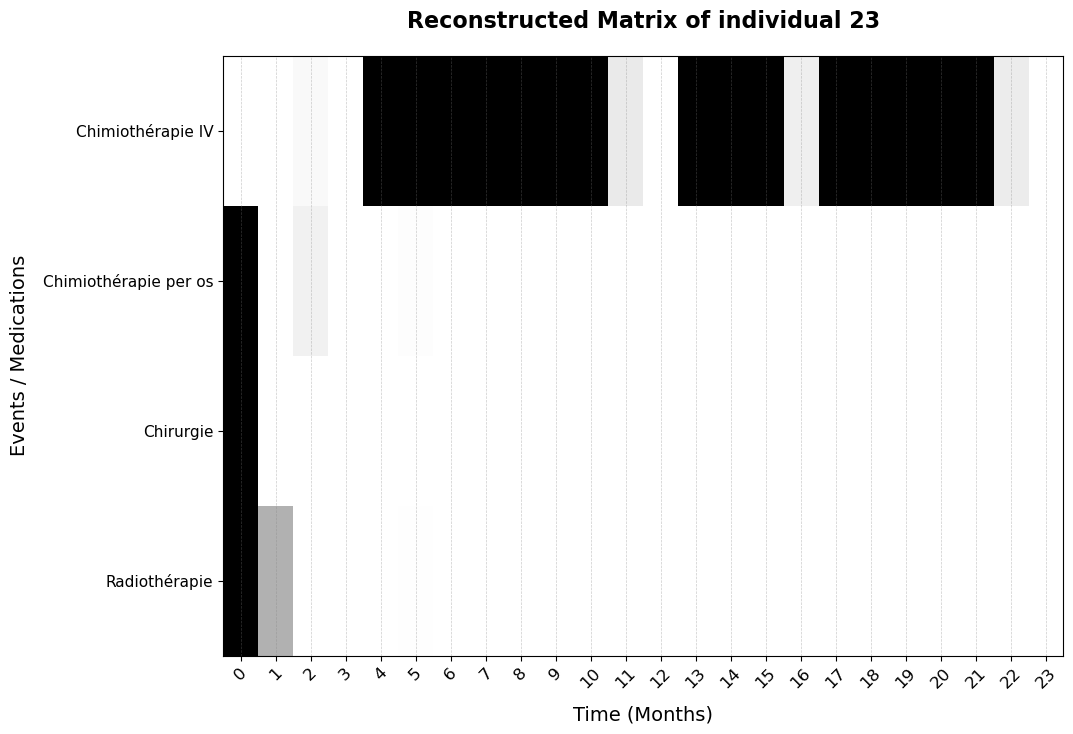

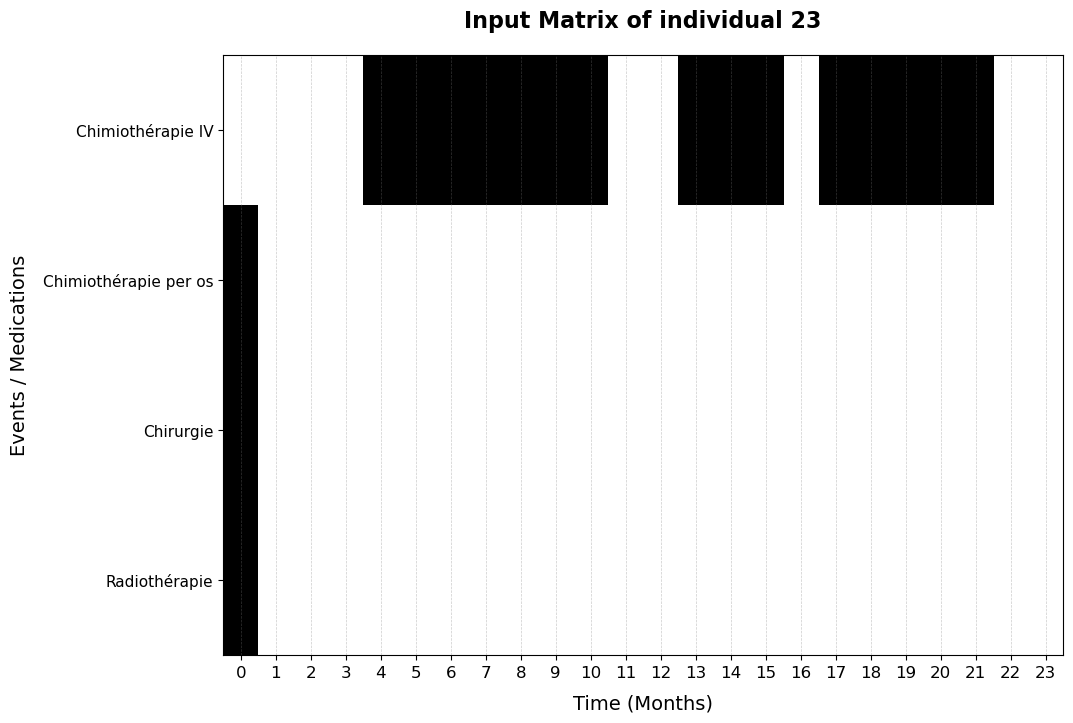

In [15]:
best_rank = 3
best_window = 3
best_reg_term_s = 0.1
best_reg_term_ns = 0.9

tca.analyzer.model, tca.analyzer.W = models[(best_rank, best_window, best_reg_term_s, best_reg_term_ns)]
tca.analyzer.get_decomposition_results(labels=noms_events, id=patient_index, time_unit='Months')

La matrice reconstruite est très proche de la matrice de base pour un rang égal à 3, une taille de fenêtre de 3 mois, et terme de sparsité de 0.1 et un terme de non-succession de 0.9.
C'est la configuration pour laquelle on a les plus petits loss au bout de 200 époques.

In [1]:
patient_index0 = int(patients_with_all_events[3])
tca.analyzer.get_decomposition_results(labels=noms_events, id=patient_index0, time_unit='Months')

NameError: name 'patients_with_all_events' is not defined

Success rate tjrs négatif ?

## 5. Clustering

### 5.1. Intensités des phénotypes :

In [17]:
from sklearn.preprocessing import MinMaxScaler
ph_intensity = tca.analyzer.to_phenotype_intensity(scaler=MinMaxScaler())
print("Shape intensites:", ph_intensity.shape)
ph_intensity.head()

Shape intensites: (1336, 4)


,Phenotype_1,Phenotype_2,Phenotype_3,ID_PATIENT
0,0.271979,0.301216,0.001485,1
1,0.330218,0.244967,0.000882,2
2,0.215310,0.584102,0.470946,3
3,0.331396,0.649179,0.001076,4
4,0.331743,0.306929,0.001098,5


### 5.2. Clustering à partir des intensités :

INFO:root:Calculating distance matrix using metric: euclidean...
INFO:root:Time taken for computation: 0.01 seconds
INFO:root:Computing the linkage matrix using method: ward...
c:\Users\imen.miloudi\OneDrive - Aix-Marseille Université\Documents\stage\TrajectoryClusteringAnalysis\src\trajectoryclusteringanalysis\unidimensional\clustering.py:238: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage_matrix = linkage(condensed_distance_matrix, method=method, optimal_ordering=optimal_ordering)
INFO:root:Linkage matrix computed successfully


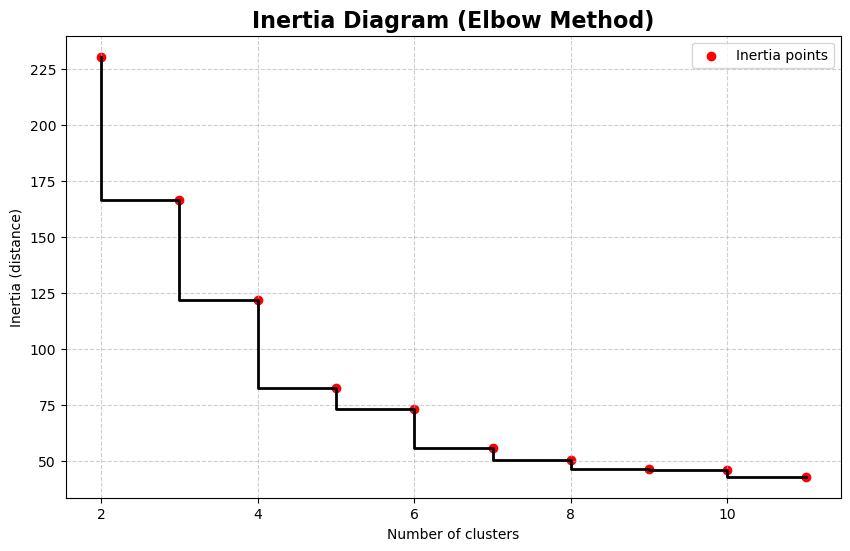

In [18]:
distance_matrix = tca.compute_distance_matrix(data=ph_intensity, metric='euclidean')
linkage_matrix = tca.hierarchical_clustering(distance_matrix)
tca.plot_inertia(linkage_matrix)

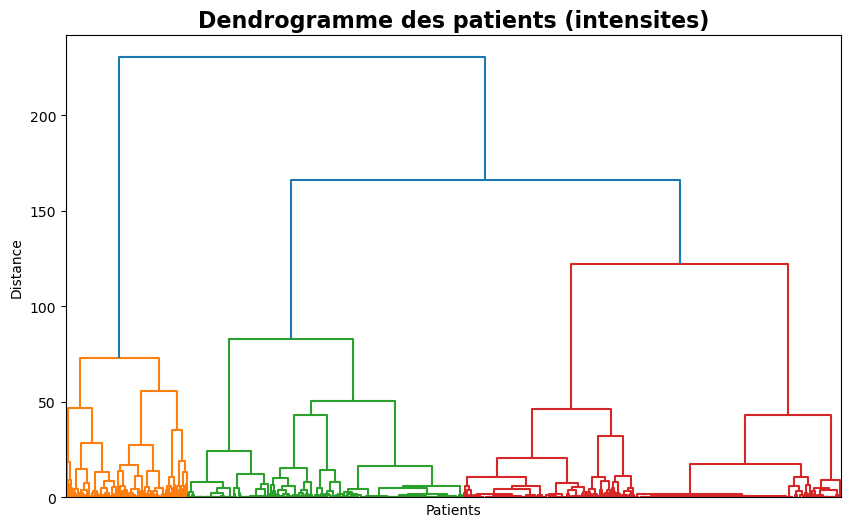

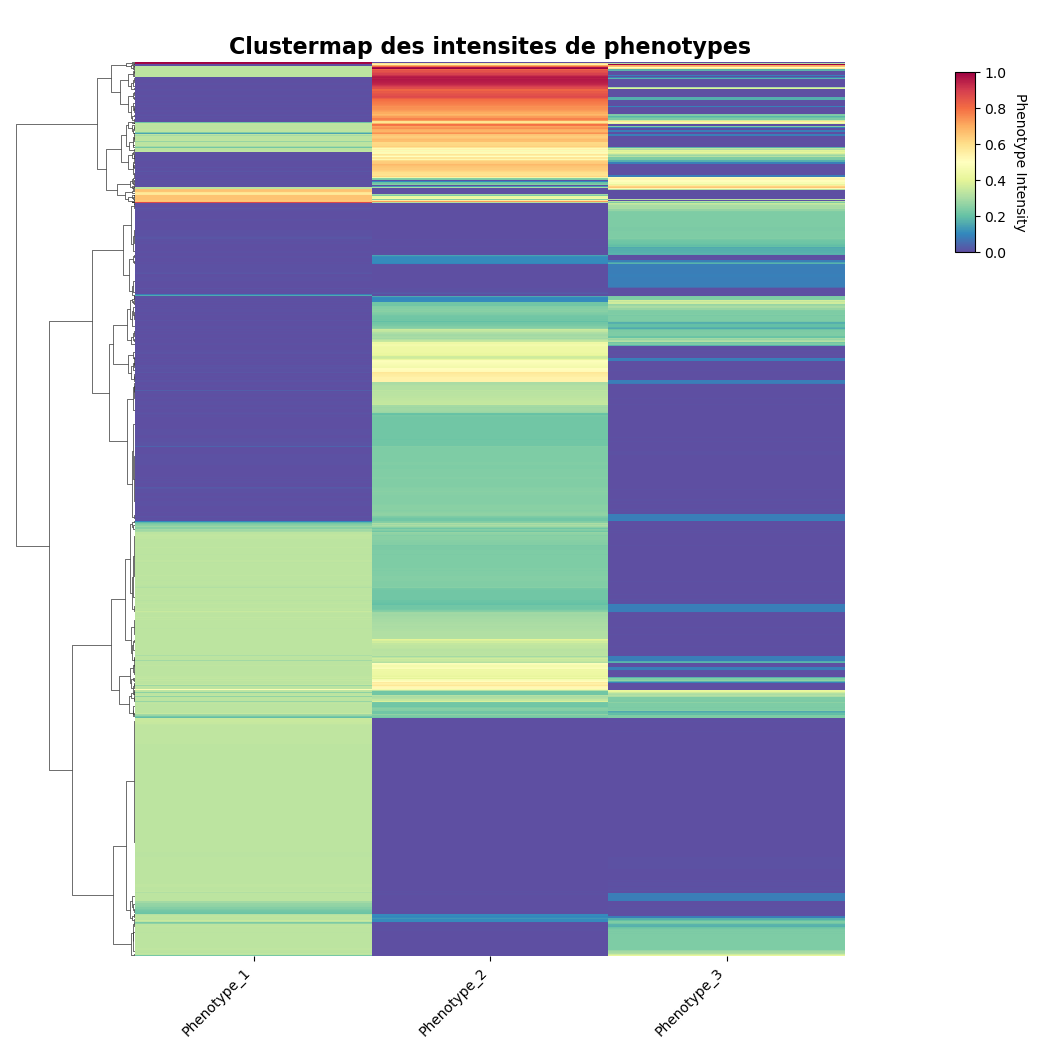

Effectifs par cluster:
1    210
2    476
3    294
4    356
Name: count, dtype: int64


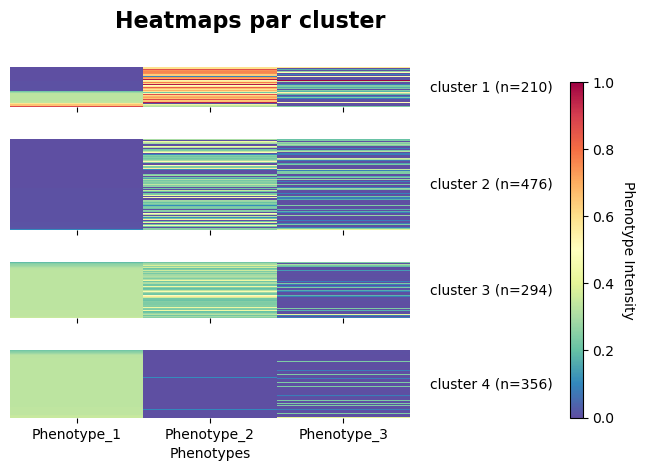

In [28]:
# Visualisations standard du package
tca.plot_dendrogram(linkage_matrix, title='Dendrogramme des patients (intensites)')
tca.plot_clustermap(ph_intensity, linkage_matrix, title='Clustermap des intensites de phenotypes')

clusters = tca.assign_clusters(linkage_matrix, num_clusters=4)
print("Effectifs par cluster:")
print(pd.Series(clusters).value_counts().sort_index())

tca.plot_cluster_heatmaps(ph_intensity, clusters, sorted=True, title='Heatmaps par cluster')

* Cluster 1 : Patients en chimiothérapie (Phénotype 2)
    - Une grande partie des patients de ce cluster ont une intensité proche de 1 pour le phénotype 2

* Cluster 2 :
    - Pour tous les patients de ce cluster, on a une intensité proche de 0 pour le phénotype 1

* Cluster 3 :
    - Une grande partie des patients ont une intensité proche de 0 pour le phénotype 3

* Cluster 4 :
    - Une grande majorité des patients ont une intensité proche de 0 pour le phénotype 2